# EEG Functional Connectivity Analysis
**USC EEG Creativity Study — AI+Human vs. Human Only**

This notebook performs:
1. **Coherence Analysis** — Magnitude-squared coherence per frequency band
2. **Phase Locking Analysis** — Phase Lag Index (PLI) per frequency band
3. **Connectivity Network Graphs** — Visualizing brain networks like MIT paper Figure 1
4. **Statistical Comparison** — AI vs Control for each connection

## 0. Imports & Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats
from itertools import combinations

import mne
from mne_connectivity import spectral_connectivity_epochs

mne.set_log_level('ERROR')

print('MNE version:', mne.__version__)
print('All imports successful!')

MNE version: 1.11.0
All imports successful!


## 1. Configuration

In [2]:
# ── PATHS ──────────────────────────────────────────────────────────────────
BASE_PATH = "/Users/agastyabassi/Library/CloudStorage/OneDrive-SharedLibraries-UniversityofSouthernCalifornia/Athena Saghi - EEG Cleaning/clean"
OUTPUT_DIR = "./connectivity_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── FREQUENCY BANDS ────────────────────────────────────────────────────────
BANDS = {
    'Delta': (1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta':  (13, 30),
    'Gamma': (30, 45),
}

# ── KEY ELECTRODE PAIRS TO FOCUS ON ────────────────────────────────────────
KEY_PAIRS = {
    'Frontal-Temporal Alpha':   [('F3','T7'), ('F4','T8'), ('F3','P7'), ('F4','P8')],
    'Frontal-Occipital Theta':  [('F3','O1'), ('F4','O2'), ('Fz','O1'), ('Fz','O2')],
    'Frontal-Parietal Alpha':   [('F3','P3'), ('F4','P4'), ('Fz','Pz')],
    'Inter-hemispheric Frontal': [('F3','F4'), ('Fp1','Fp2')],
}

# ── EPOCH LENGTH FOR CONNECTIVITY ──────────────────────────────────────────
EPOCH_LENGTH = 4.0  # seconds

# ── NON BRAIN CHANNELS TO REMOVE ───────────────────────────────────────────
NON_BRAIN = ['A1', 'A2', 'REF', 'GND']

print('Configuration loaded!')

Configuration loaded!


## 2. Load Files

In [3]:
def get_file_lists(base_path):
    all_files = glob.glob(os.path.join(base_path, '*.set'))
    control_files   = sorted([f for f in all_files if '_control_'   in os.path.basename(f)])
    treatment_files = sorted([f for f in all_files if '_treatment_' in os.path.basename(f)])
    
    # Keep only participants with BOTH conditions
    ctrl_subjects = set(os.path.basename(f).split('_')[0] for f in control_files)
    trt_subjects  = set(os.path.basename(f).split('_')[0] for f in treatment_files)
    common = ctrl_subjects & trt_subjects
    
    control_files   = [f for f in control_files   if os.path.basename(f).split('_')[0] in common]
    treatment_files = [f for f in treatment_files if os.path.basename(f).split('_')[0] in common]
    
    print(f'Control files:   {len(control_files)}')
    print(f'Treatment files: {len(treatment_files)}')
    print(f'Participants:    {sorted(common)}')
    return control_files, treatment_files

control_files, treatment_files = get_file_lists(BASE_PATH)

Control files:   36
Treatment files: 38
Participants:    ['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9']


## 3. Core Helper — Load & Epoch Raw Data

In [4]:
def load_and_epoch(filepath, epoch_length=4.0, non_brain=NON_BRAIN):
    """
    Load a .set file, remove non-brain channels,
    and cut into fixed-length epochs for connectivity analysis.
    """
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
    
    # Remove non-brain channels
    drop = [ch for ch in non_brain if ch in raw.ch_names]
    if drop:
        raw.drop_channels(drop)
    
    # Set standard montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')
    
    # Create fixed length epochs
    events = mne.make_fixed_length_events(raw, duration=epoch_length)
    epochs = mne.Epochs(raw, events, tmin=0, tmax=epoch_length,
                        baseline=None, preload=True, verbose=False)
    return epochs

print('Helper defined!')

Helper defined!


## 4. Compute Connectivity Per File

In [5]:
def compute_connectivity(filepath, bands, method='coh', epoch_length=4.0):
    """
    Compute spectral connectivity (coherence or PLI) for all electrode pairs.
    Returns:
        conn_matrix: dict of band -> (n_channels x n_channels) connectivity matrix
        ch_names: list of channel names
    """
    epochs = load_and_epoch(filepath, epoch_length)
    ch_names = epochs.ch_names
    sfreq = epochs.info['sfreq']
    
    # Get all frequency limits
    fmin = [v[0] for v in bands.values()]
    fmax = [v[1] for v in bands.values()]
    
    # Compute connectivity
    conn = spectral_connectivity_epochs(
        epochs,
        method=method,
        mode='multitaper',
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        verbose=False
    )
    
    # Extract connectivity matrices per band
    n_ch = len(ch_names)
    conn_data = conn.get_data()  # shape: (n_connections, n_bands)
    
    conn_matrices = {}
    for b_idx, band_name in enumerate(bands.keys()):
        mat = np.zeros((n_ch, n_ch))
        idx = 0
        for i in range(n_ch):
            for j in range(i+1, n_ch):
                mat[i, j] = conn_data[idx, b_idx]
                mat[j, i] = conn_data[idx, b_idx]
                idx += 1
        conn_matrices[band_name] = mat
    
    return conn_matrices, ch_names

print('Connectivity function defined!')

Connectivity function defined!


## 5. Process All Files

In [6]:
def process_all_connectivity(file_list, bands, method='coh', label=''):
    """
    Process all files for one condition.
    Returns list of dicts with subject, block, conn_matrices, ch_names.
    """
    results = []
    for fpath in file_list:
        fname   = os.path.basename(fpath)
        subject = fname.split('_')[0]
        block   = fname.split('_')[2]
        try:
            conn_matrices, ch_names = compute_connectivity(fpath, bands, method=method)
            results.append({
                'subject':       subject,
                'block':         block,
                'conn_matrices': conn_matrices,
                'ch_names':      ch_names,
                'file':          fname
            })
            print(f'  ✓ {fname}')
        except Exception as e:
            print(f'  ✗ {fname}: {e}')
    return results

print('Computing COHERENCE for control...')
ctrl_coh  = process_all_connectivity(control_files,   BANDS, method='coh', label='control')
print(f'\nComputing COHERENCE for treatment...')
trt_coh   = process_all_connectivity(treatment_files, BANDS, method='coh', label='treatment')

print(f'\nDone! {len(ctrl_coh)} control, {len(trt_coh)} treatment sessions.')

Computing COHERENCE for control...


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz corresponds to 4.003 < 5 cycles based on the epoch length 4.003 sec, need at least 5.000 sec epochs or fmin=1.249. Spectrum estimate will be unreliable.
  conn = spectral_connectivity_epochs(


  ✓ P10_control_A3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz corresponds to 4.003 < 5 cycles based on the epoch length 4.003 sec, need at least 5.000 sec epochs or fmin=1.249. 

  ✓ P10_control_B2_postcleaning1.set


...

  ✓ P7_treatment_B3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Data file name in EEG.data (P9_treatment_A2_postcleaning1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (P9_treatment_A4_postcleaning1.fdt).
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz 

  ✓ P9_treatment_A4_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz corresponds to 4.003 < 5 cycles based on the epoch length 4.003 sec, need at least 5.000 sec epochs or fmin=1.249. Spectrum estimate will be unreliable.
  conn = spectral_connectivity_epochs(


  ✓ P9_treatment_B2_postcleaning1.set

Done! 36 control, 37 treatment sessions.


## 6. Grand Average Connectivity Matrices

In [7]:
def grand_average_connectivity(results, bands):
    """
    Average connectivity matrices across all sessions.
    Returns dict: band -> mean matrix (n_ch x n_ch)
    """
    if not results:
        return None, None
    
    # Find common channels
    all_ch_sets = [set(r['ch_names']) for r in results]
    common_chs  = sorted(set.intersection(*all_ch_sets))
    
    ga = {}
    for band in bands:
        mats = []
        for r in results:
            idx = [r['ch_names'].index(c) for c in common_chs]
            mat = r['conn_matrices'][band][np.ix_(idx, idx)]
            mats.append(mat)
        ga[band] = np.mean(mats, axis=0)
    
    return ga, common_chs

ga_coh_ctrl, common_chs = grand_average_connectivity(ctrl_coh,  BANDS)
ga_coh_trt,  _          = grand_average_connectivity(trt_coh,   BANDS)

print(f'Grand average computed!')
print(f'Common channels ({len(common_chs)}): {common_chs}')

Grand average computed!
Common channels (19): ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8']


## 7. Connectivity Matrix Heatmaps

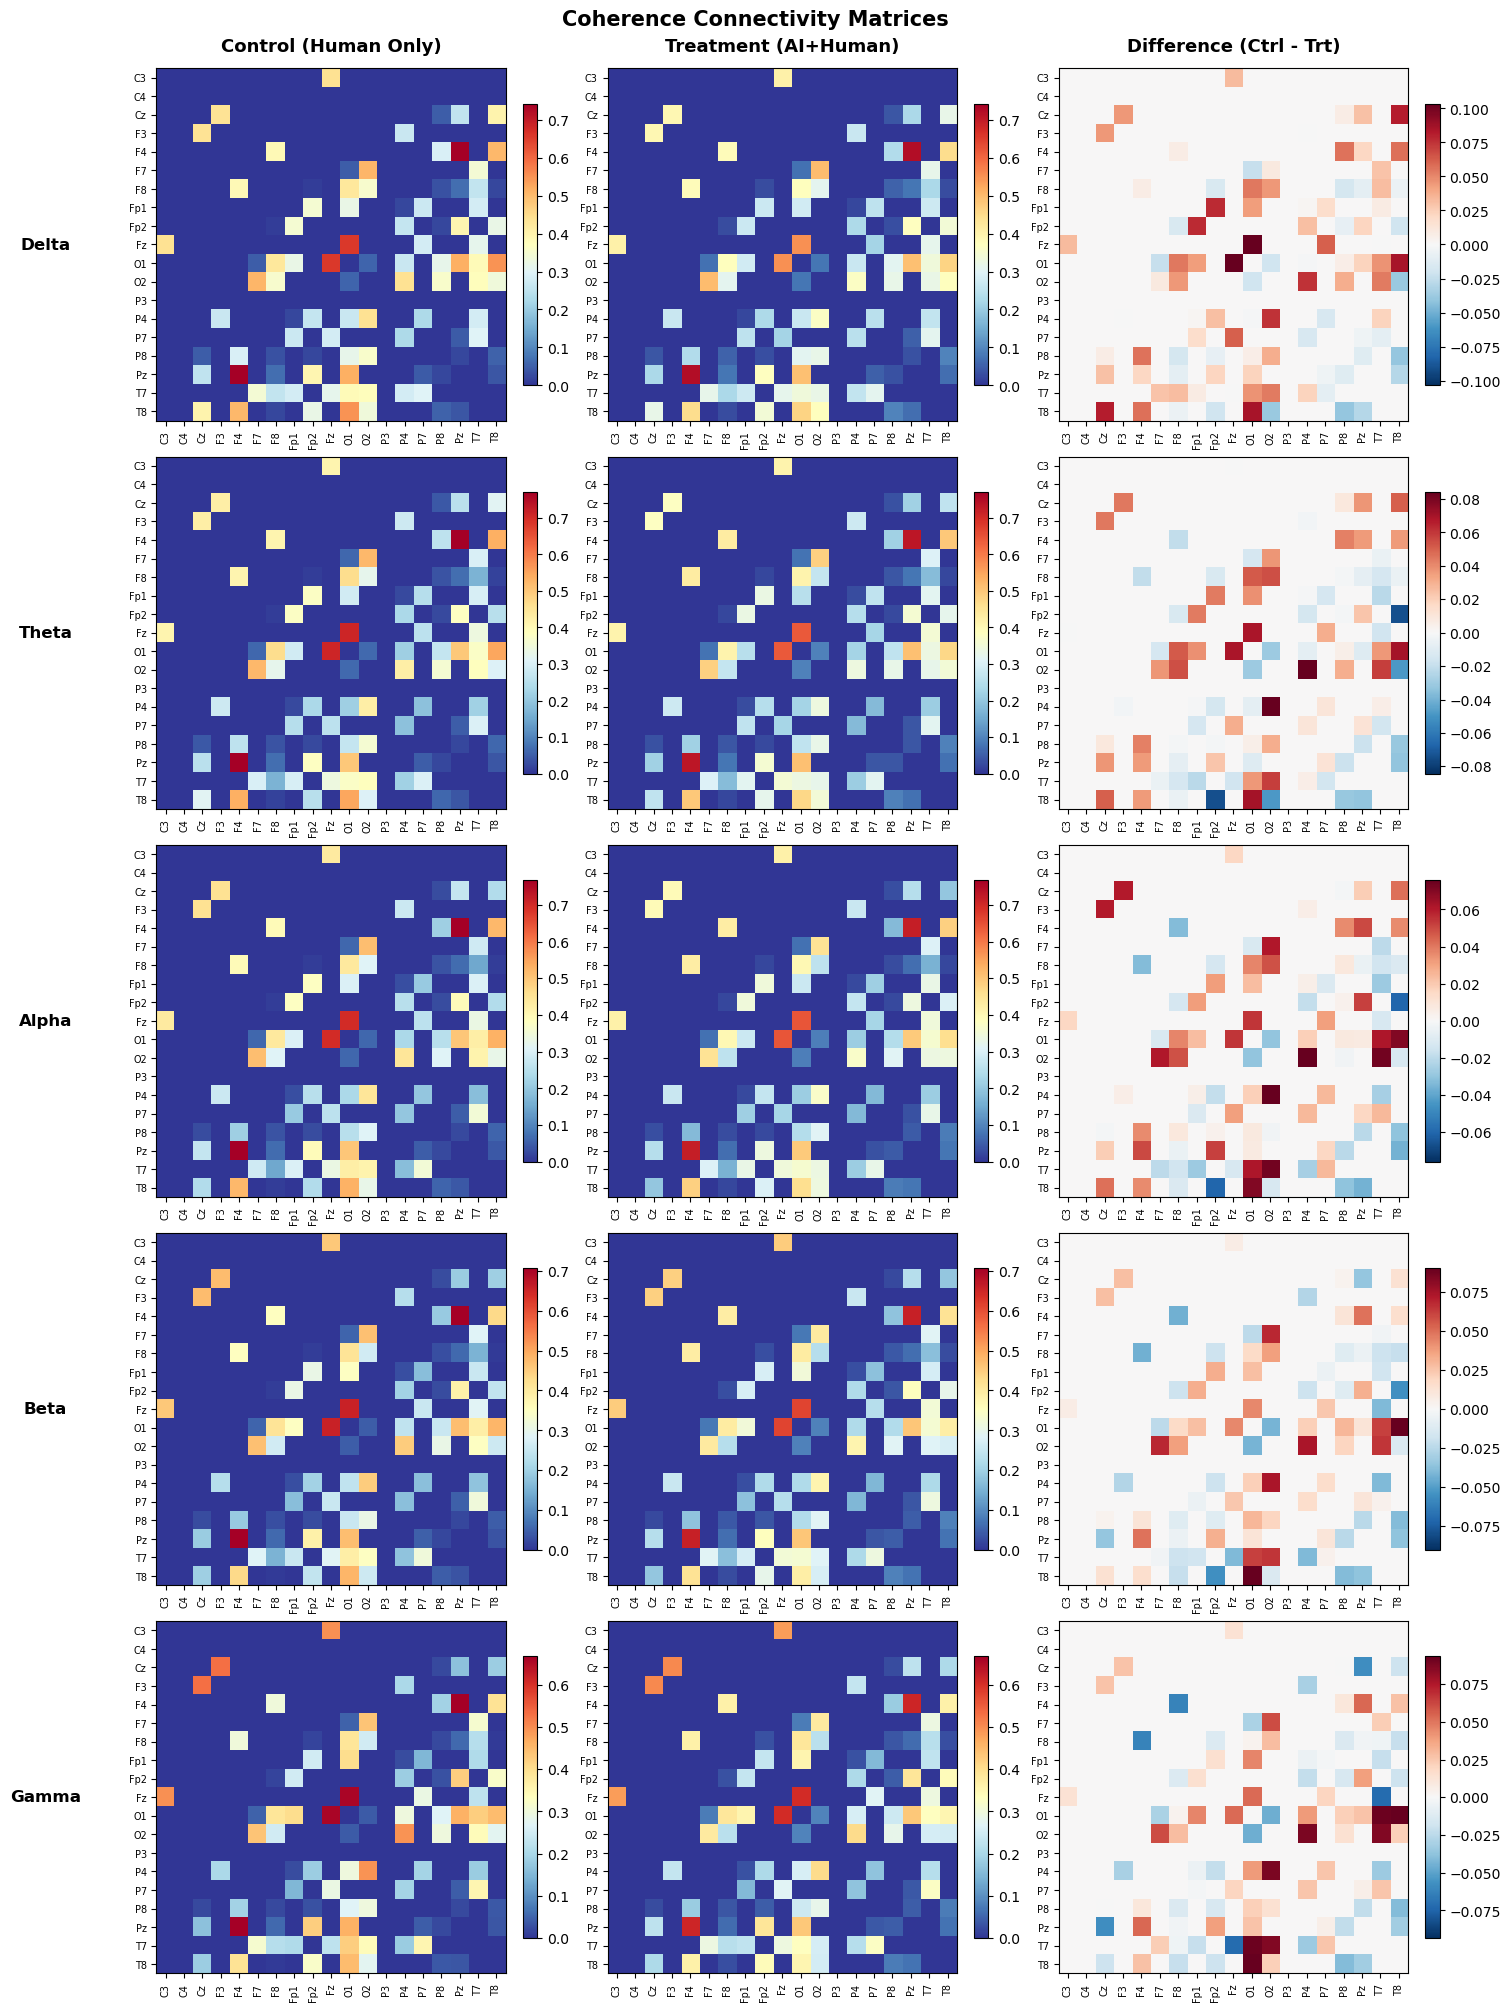

Saved: coherence_matrices.png


In [9]:
def plot_connectivity_matrices(ga_ctrl, ga_trt, ch_names, bands_to_plot=None):
    """
    Plot connectivity matrices as heatmaps:
    Control | Treatment | Difference
    """
    if bands_to_plot is None:
        bands_to_plot = list(BANDS.keys())
    
    fig, axes = plt.subplots(len(bands_to_plot), 3,
                             figsize=(15, 4 * len(bands_to_plot)),
                             constrained_layout=True)
    
    if len(bands_to_plot) == 1:
        axes = axes[np.newaxis, :]
    
    col_titles = ['Control (Human Only)', 'Treatment (AI+Human)', 'Difference (Ctrl - Trt)']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=13, fontweight='bold', pad=12)
    
    for row, band in enumerate(bands_to_plot):
        ctrl_mat = ga_ctrl[band]
        trt_mat  = ga_trt[band]
        diff_mat = ctrl_mat - trt_mat
        
        vmin = min(ctrl_mat.min(), trt_mat.min())
        vmax = max(ctrl_mat.max(), trt_mat.max())
        vm   = max(abs(diff_mat.min()), abs(diff_mat.max()))
        
        for col, (mat, cm, vmn, vmx) in enumerate([
            (ctrl_mat, 'RdYlBu_r', vmin, vmax),
            (trt_mat,  'RdYlBu_r', vmin, vmax),
            (diff_mat, 'RdBu_r',   -vm,  vm)
        ]):
            im = axes[row, col].imshow(mat, cmap=cm, vmin=vmn, vmax=vmx, aspect='auto')
            axes[row, col].set_xticks(range(len(ch_names)))
            axes[row, col].set_yticks(range(len(ch_names)))
            axes[row, col].set_xticklabels(ch_names, rotation=90, fontsize=7)
            axes[row, col].set_yticklabels(ch_names, fontsize=7)
            plt.colorbar(im, ax=axes[row, col], shrink=0.8)
        
        axes[row, 0].set_ylabel(band, fontsize=12, fontweight='bold',
                                rotation=0, labelpad=60, va='center')
    
    plt.suptitle('Coherence Connectivity Matrices', fontsize=15, fontweight='bold')
    plt.savefig(os.path.join(OUTPUT_DIR, 'coherence_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: coherence_matrices.png')

plot_connectivity_matrices(ga_coh_ctrl, ga_coh_trt, common_chs)

## 8. Connectivity Network Graphs (like MIT paper Figure 1)

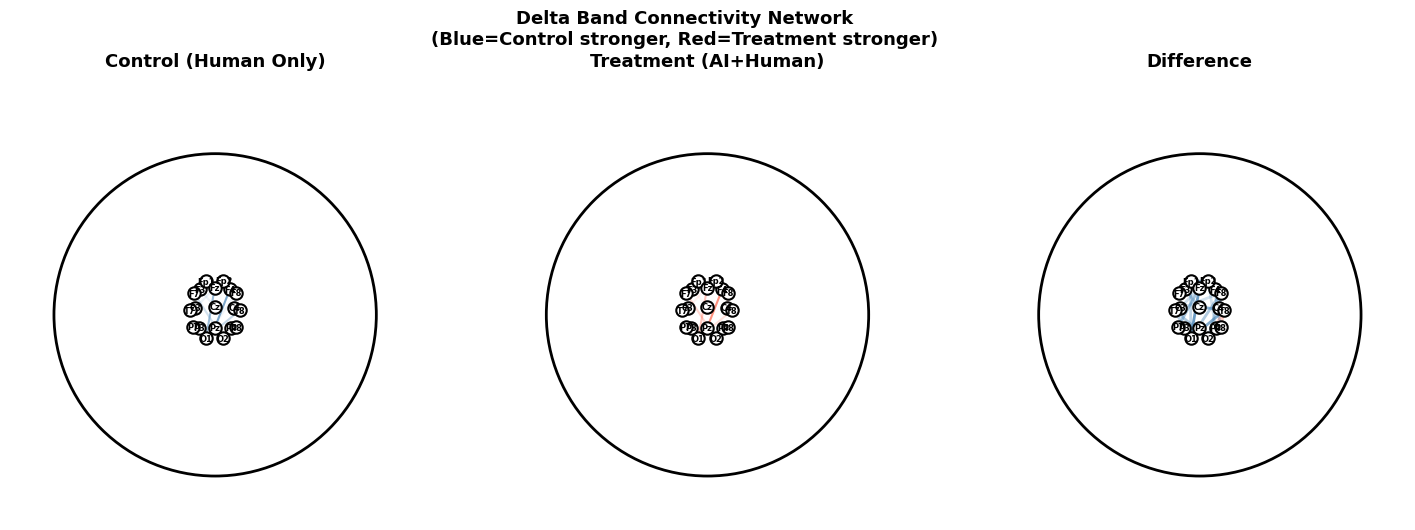

Saved: network_Delta.png


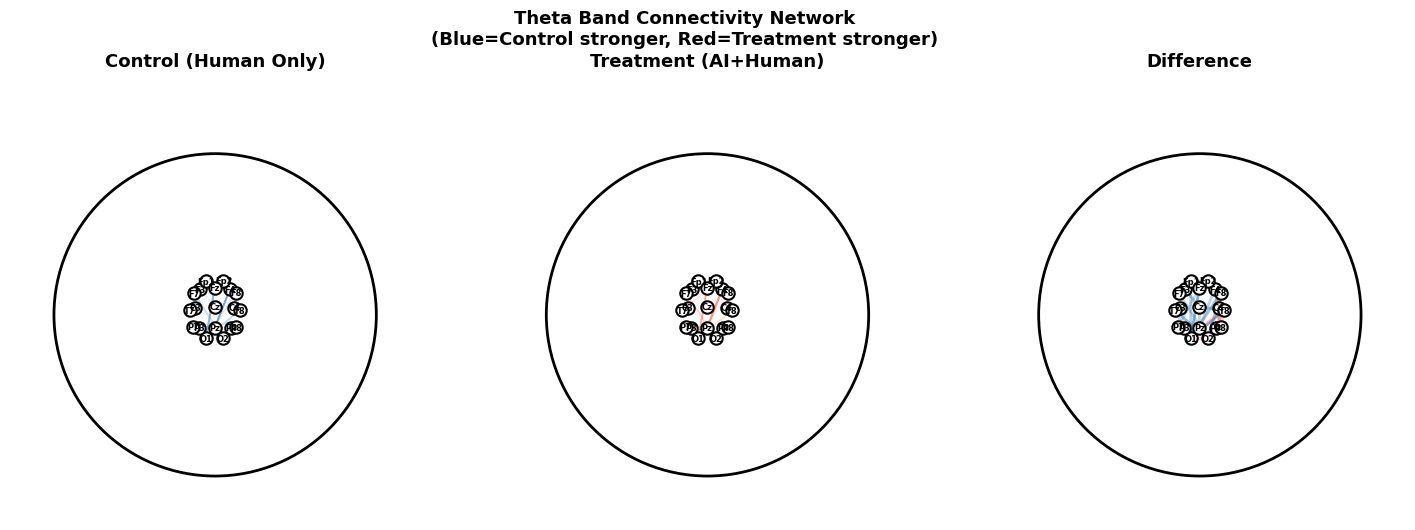

Saved: network_Theta.png


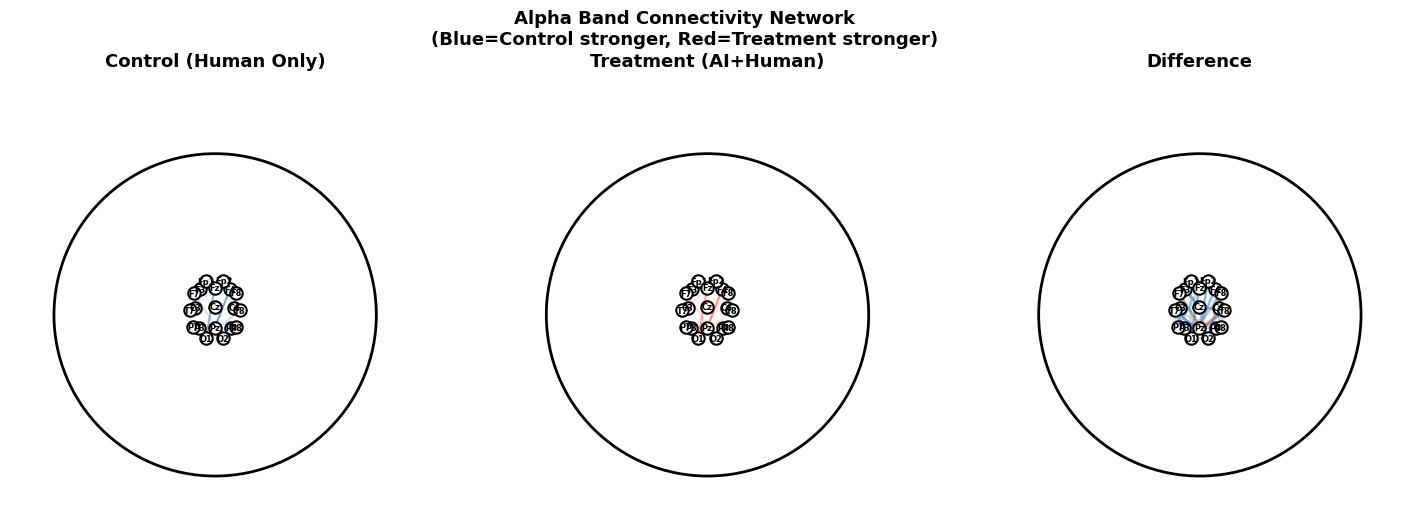

Saved: network_Alpha.png


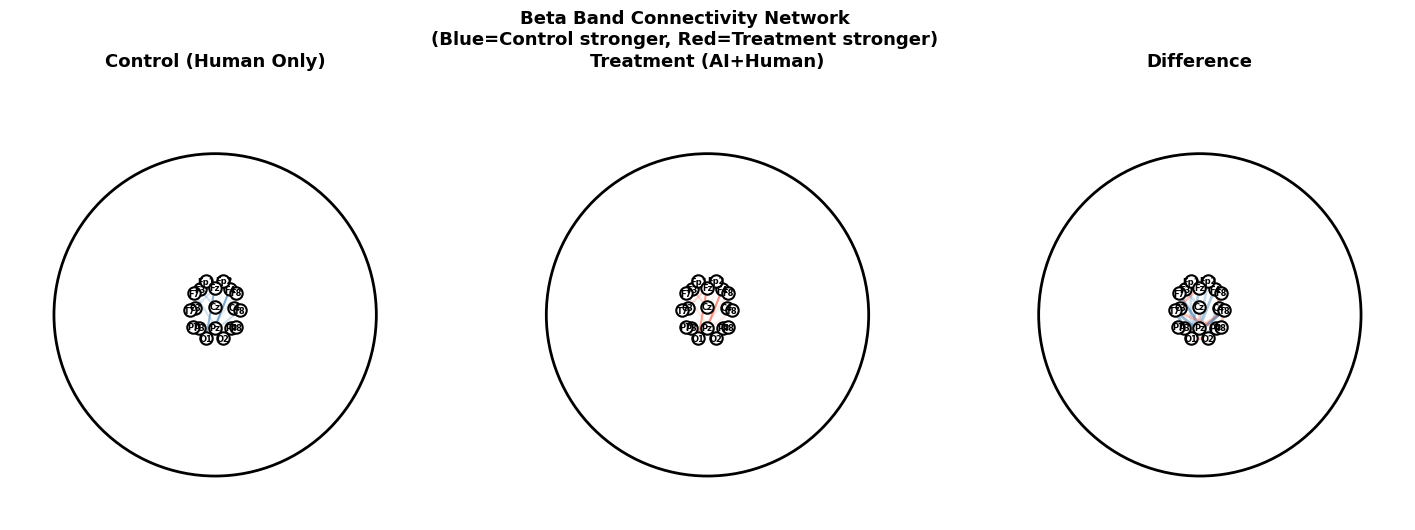

Saved: network_Beta.png


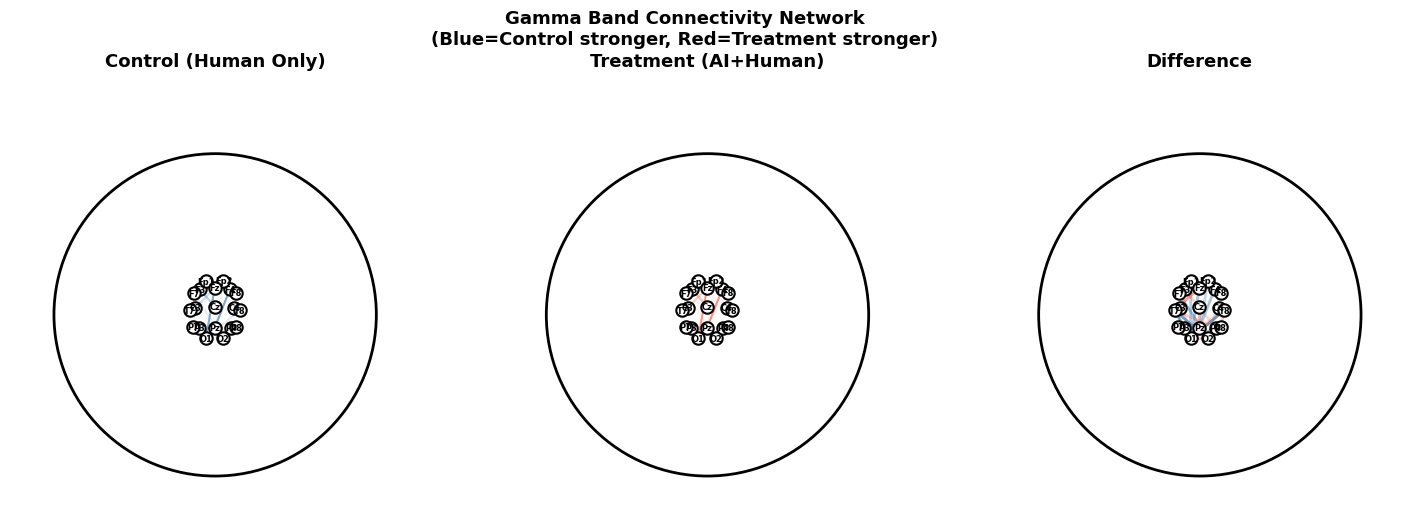

Saved: network_Gamma.png


In [10]:
def plot_connectivity_network(ga_ctrl, ga_trt, ch_names, band='Alpha', threshold_pct=75):
    """
    Plot brain connectivity network on head diagram.
    Only shows connections above threshold_pct percentile.
    Similar to MIT paper Figure 1.
    """
    # Get electrode positions
    info = mne.create_info(ch_names, sfreq=256, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage, on_missing='ignore')
    
    # Get 2D positions
    pos_2d = np.array([info['chs'][i]['loc'][:2] for i in range(len(ch_names))])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    titles = ['Control (Human Only)', 'Treatment (AI+Human)', 'Difference']
    
    ctrl_mat = ga_ctrl[band].copy()
    trt_mat  = ga_trt[band].copy()
    diff_mat = ctrl_mat - trt_mat
    
    np.fill_diagonal(ctrl_mat, 0)
    np.fill_diagonal(trt_mat,  0)
    
    threshold_ctrl = np.percentile(ctrl_mat[ctrl_mat > 0], threshold_pct)
    threshold_trt  = np.percentile(trt_mat[trt_mat   > 0], threshold_pct)
    
    for ax_idx, (ax, title) in enumerate(zip(axes, titles)):
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.axis('off')
        
        # Draw head circle
        circle = plt.Circle((0, 0), 0.55, fill=False, color='black', linewidth=2)
        ax.add_patch(circle)
        ax.set_xlim(-0.7, 0.7)
        ax.set_ylim(-0.7, 0.8)
        
        if ax_idx < 2:
            mat = ctrl_mat if ax_idx == 0 else trt_mat
            threshold = threshold_ctrl if ax_idx == 0 else threshold_trt
            color = 'steelblue' if ax_idx == 0 else 'tomato'
            
            # Draw connections
            for i in range(len(ch_names)):
                for j in range(i+1, len(ch_names)):
                    if mat[i, j] > threshold:
                        x = [pos_2d[i, 0], pos_2d[j, 0]]
                        y = [pos_2d[i, 1], pos_2d[j, 1]]
                        alpha = min((mat[i,j] - threshold) / (mat.max() - threshold), 1.0)
                        ax.plot(x, y, color=color, alpha=alpha * 0.7, linewidth=1.5)
        else:
            # Difference plot — blue = control stronger, red = treatment stronger
            vm = np.abs(diff_mat).max()
            for i in range(len(ch_names)):
                for j in range(i+1, len(ch_names)):
                    val = diff_mat[i, j]
                    if abs(val) > vm * 0.3:  # only show notable differences
                        x = [pos_2d[i, 0], pos_2d[j, 0]]
                        y = [pos_2d[i, 1], pos_2d[j, 1]]
                        color = 'steelblue' if val > 0 else 'tomato'
                        alpha = min(abs(val) / vm, 1.0)
                        ax.plot(x, y, color=color, alpha=alpha * 0.8, linewidth=2)
        
        # Draw electrodes
        for i, ch in enumerate(ch_names):
            ax.scatter(pos_2d[i, 0], pos_2d[i, 1], s=80, c='white',
                      edgecolors='black', zorder=5, linewidth=1.5)
            ax.text(pos_2d[i, 0], pos_2d[i, 1], ch, fontsize=6,
                   ha='center', va='center', zorder=6, fontweight='bold')
    
    plt.suptitle(f'{band} Band Connectivity Network\n(Blue=Control stronger, Red=Treatment stronger)',
                fontsize=13, fontweight='bold')
    fname = os.path.join(OUTPUT_DIR, f'network_{band}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: network_{band}.png')


# Plot for each band
for band in BANDS:
    plot_connectivity_network(ga_coh_ctrl, ga_coh_trt, common_chs, band=band)

## 9. Phase Locking Index (PLI)

Computing PLI for control...


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz corresponds to 4.003 < 5 cycles based on the epoch length 4.003 sec, need at least 5.000 sec epochs or fmin=1.249. Spectrum estimate will be unreliable.
  conn = spectral_connectivity_epochs(


  ✓ P10_control_A3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz corresponds to 4.003 < 5 cycles based on the epoch length 4.003 sec, need at least 5.000 sec epochs or fmin=1.249. 

  ✓ P10_control_B2_postcleaning1.set


...

  ✓ P7_treatment_B3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Data file name in EEG.data (P9_treatment_A2_postcleaning1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (P9_treatment_A4_postcleaning1.fdt).
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz 

  ✓ P9_treatment_A4_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/2716071070.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_69066/855772541.py:17: RuntimeWarning: fmin=1.000 Hz corresponds to 4.003 < 5 cycles based on the epoch length 4.003 sec, need at least 5.000 sec epochs or fmin=1.249. Spectrum estimate will be unreliable.
  conn = spectral_connectivity_epochs(


  ✓ P9_treatment_B2_postcleaning1.set

PLI computed! Plotting networks...


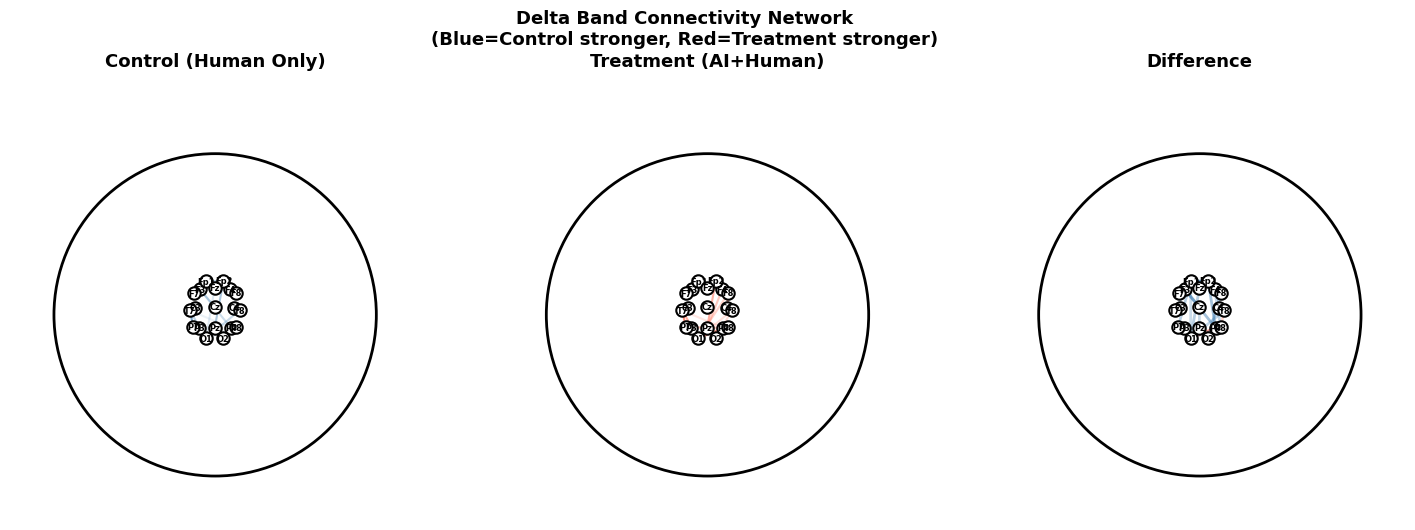

Saved: network_Delta.png


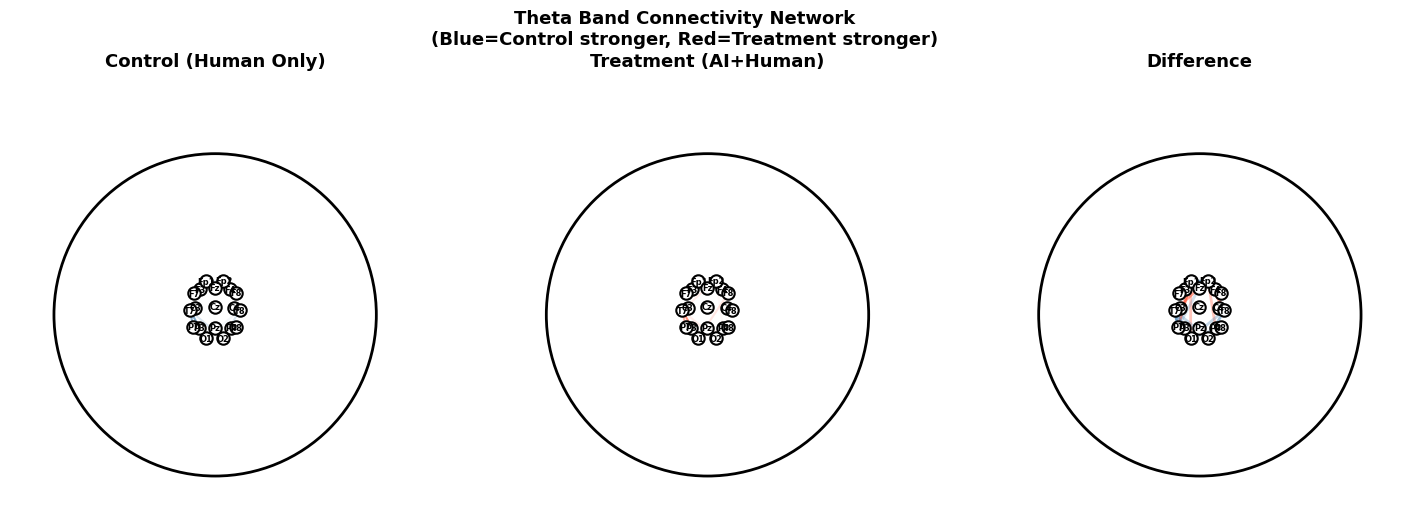

Saved: network_Theta.png


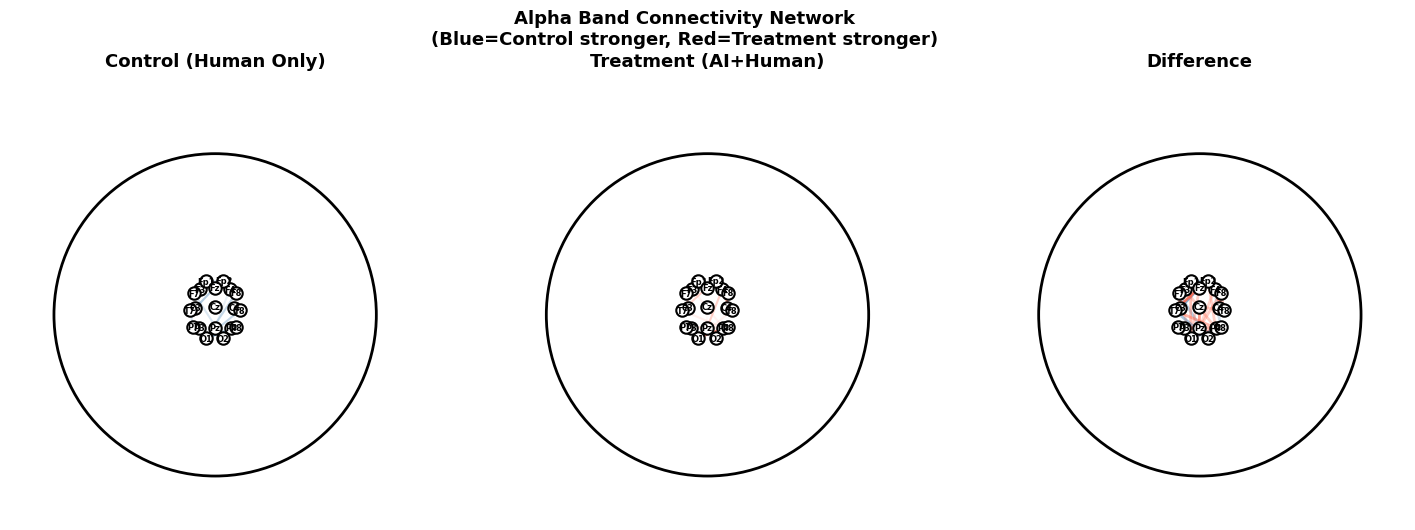

Saved: network_Alpha.png


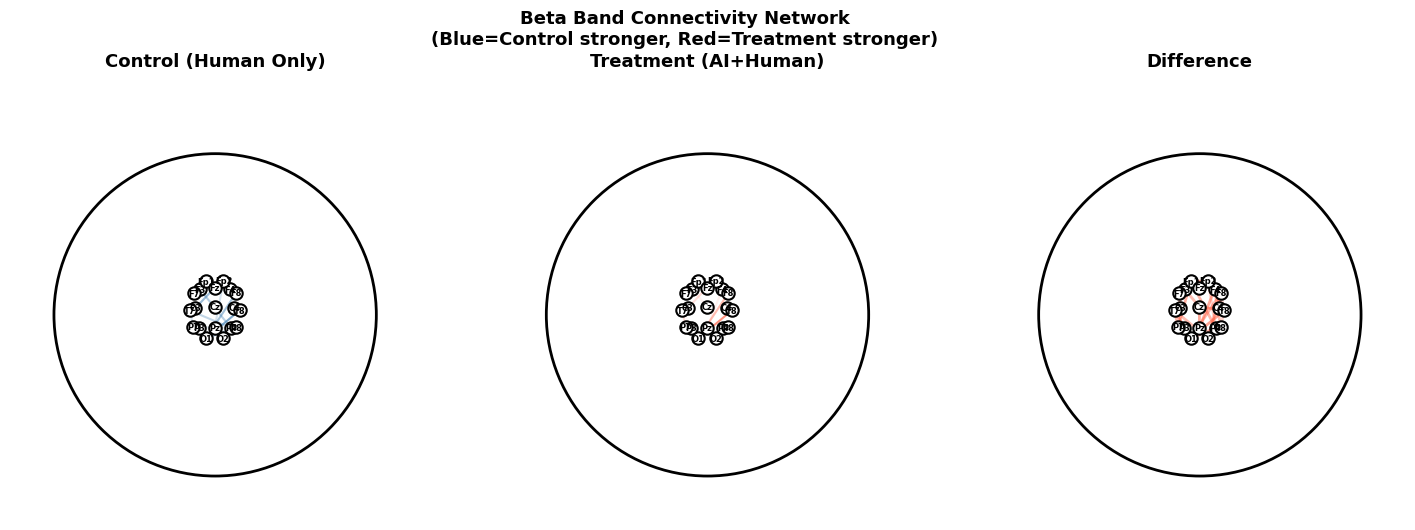

Saved: network_Beta.png


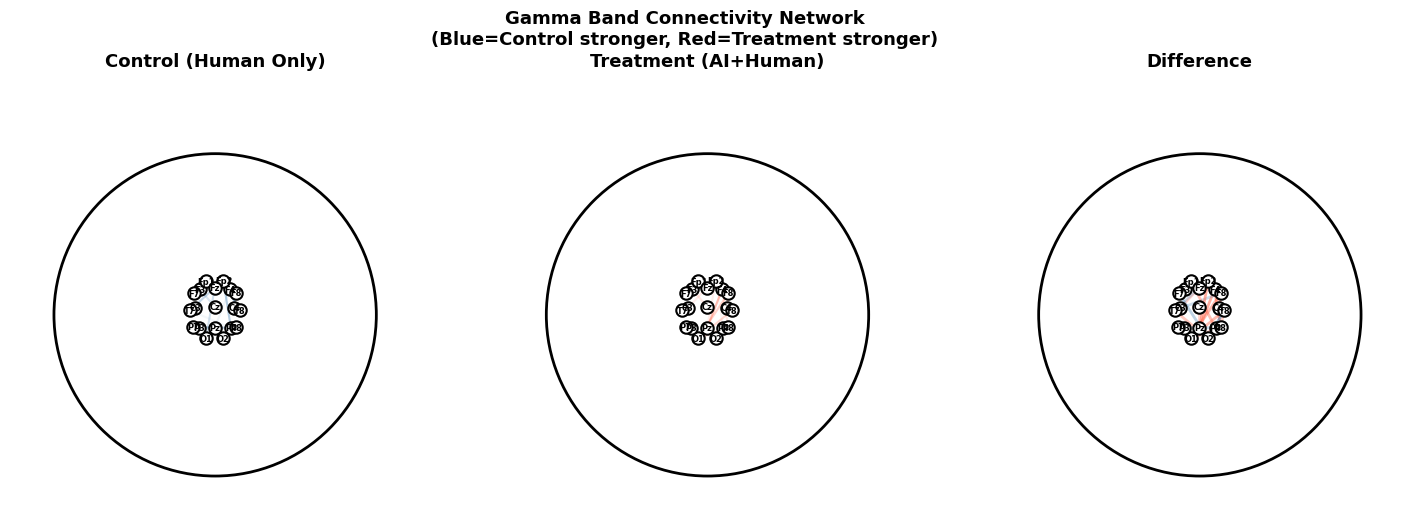

Saved: network_Gamma.png


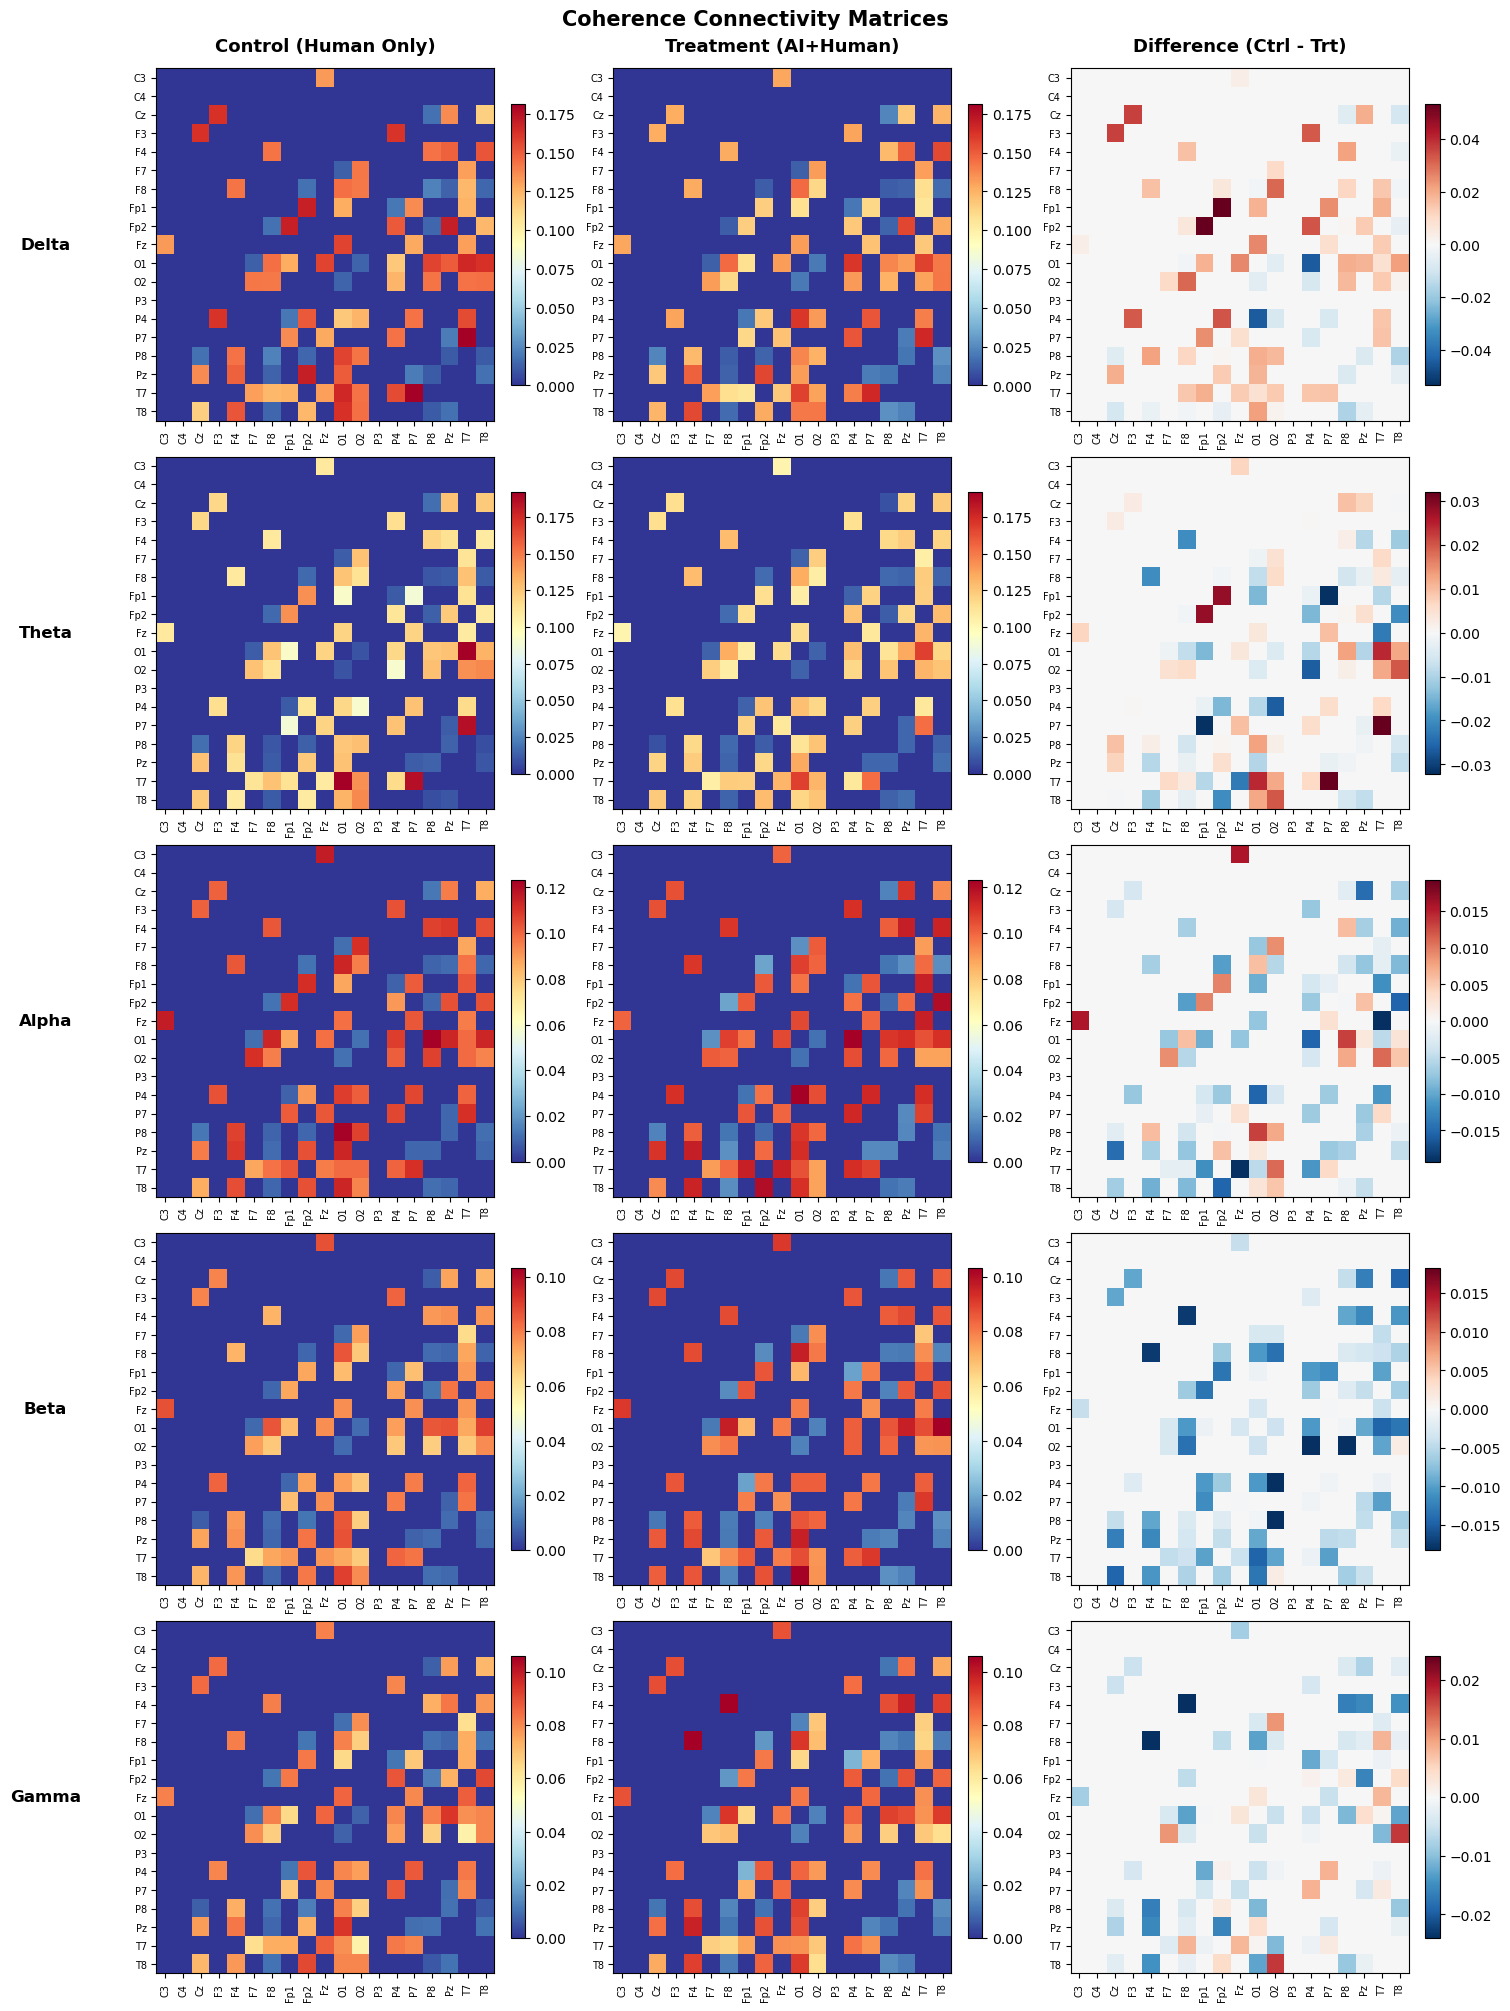

Saved: coherence_matrices.png


<Figure size 640x480 with 0 Axes>

In [13]:
print('Computing PLI for control...')
ctrl_pli = process_all_connectivity(control_files,   BANDS, method='pli', label='control')
print(f'\nComputing PLI for treatment...')
trt_pli  = process_all_connectivity(treatment_files, BANDS, method='pli', label='treatment')

ga_pli_ctrl, _ = grand_average_connectivity(ctrl_pli, BANDS)
ga_pli_trt,  _ = grand_average_connectivity(trt_pli,  BANDS)

print(f'\nPLI computed! Plotting networks...')
for band in BANDS:
    plot_connectivity_network(ga_pli_ctrl, ga_pli_trt, common_chs, band=band)
    
# Save PLI matrices
plot_connectivity_matrices(ga_pli_ctrl, ga_pli_trt, common_chs)
plt.savefig(os.path.join(OUTPUT_DIR, 'pli_matrices.png'), dpi=150, bbox_inches='tight')

## 10. Statistical Comparison — Key Electrode Pairs

In [14]:
def stats_key_pairs(ctrl_results, trt_results, key_pairs, bands, common_chs):
    """
    Run paired t-tests on key electrode pairs for each band.
    """
    from mne.stats import fdr_correction
    
    ctrl_subjects = set(r['subject'] for r in ctrl_results)
    trt_subjects  = set(r['subject'] for r in trt_results)
    common_subj   = sorted(ctrl_subjects & trt_subjects)
    print(f'Common subjects: {len(common_subj)}')
    
    rows = []
    for group_name, pairs in key_pairs.items():
        for ch1, ch2 in pairs:
            if ch1 not in common_chs or ch2 not in common_chs:
                continue
            i = common_chs.index(ch1)
            j = common_chs.index(ch2)
            
            for band in bands:
                ctrl_vals, trt_vals = [], []
                for subj in common_subj:
                    c = [r['conn_matrices'][band][i,j] for r in ctrl_results if r['subject']==subj
                         and band in r['conn_matrices']]
                    t = [r['conn_matrices'][band][i,j] for r in trt_results  if r['subject']==subj
                         and band in r['conn_matrices']]
                    if c and t:
                        ctrl_vals.append(np.mean(c))
                        trt_vals.append(np.mean(t))
                
                if len(ctrl_vals) >= 3:
                    t_stat, p_val = stats.ttest_rel(ctrl_vals, trt_vals)
                    rows.append({
                        'group':      group_name,
                        'pair':       f'{ch1}-{ch2}',
                        'band':       band,
                        't_stat':     t_stat,
                        'p_val':      p_val,
                        'ctrl_mean':  np.mean(ctrl_vals),
                        'trt_mean':   np.mean(trt_vals),
                    })
    
    df = pd.DataFrame(rows)
    if len(df) > 0:
        _, df['p_fdr'] = fdr_correction(df['p_val'], alpha=0.05)
        df['sig'] = df['p_val'] < 0.05
        df['sig_fdr'] = df['p_fdr'] < 0.05
    return df


print('=== COHERENCE STATS — KEY PAIRS ===')
coh_stats = stats_key_pairs(ctrl_coh, trt_coh, KEY_PAIRS, BANDS, common_chs)
sig = coh_stats[coh_stats['sig']]
print(f'Significant (p<0.05): {len(sig)}')
if len(sig) > 0:
    print(sig[['group','pair','band','t_stat','p_val','ctrl_mean','trt_mean']].to_string(index=False))

coh_stats.to_csv(os.path.join(OUTPUT_DIR, 'coherence_stats.csv'), index=False)
print('\nSaved: coherence_stats.csv')

=== COHERENCE STATS — KEY PAIRS ===
Common subjects: 18
Significant (p<0.05): 5
                  group  pair  band    t_stat    p_val  ctrl_mean  trt_mean
 Frontal-Temporal Alpha F4-P8 Gamma -2.139410 0.047205   0.300242  0.370291
Frontal-Occipital Theta F3-O1 Gamma -2.229935 0.039522   0.223650  0.293532
 Frontal-Parietal Alpha F3-P3 Delta  2.200647 0.041871   0.655711  0.558467
 Frontal-Parietal Alpha F3-P3  Beta  2.130233 0.048056   0.661634  0.619224
 Frontal-Parietal Alpha F3-P3 Gamma  2.670368 0.016142   0.664220  0.609266

Saved: coherence_stats.csv


In [16]:
print('=== PLI STATS — KEY PAIRS ===')
pli_stats = stats_key_pairs(ctrl_pli, trt_pli, KEY_PAIRS, BANDS, common_chs)
sig_pli = pli_stats[pli_stats['sig']]
print(f'Significant (p<0.05): {len(sig_pli)}')
if len(sig_pli) > 0:
    print(sig_pli[['group','pair','band','t_stat','p_val','ctrl_mean','trt_mean']].to_string(index=False))

pli_stats.to_csv(os.path.join(OUTPUT_DIR, 'pli_stats.csv'), index=False)
print('\nSaved: pli_stats.csv')

print('\n--- Mean PLI Per Band ---')
print(f'{"Band":<10} {"Control":>12} {"Treatment":>12} {"Ctrl>Trt?":>12}')
print('-' * 48)
for band in BANDS:
    c = ga_pli_ctrl[band].copy()
    t = ga_pli_trt[band].copy()
    np.fill_diagonal(c, 0)
    np.fill_diagonal(t, 0)
    c_mean = c[c>0].mean()
    t_mean = t[t>0].mean()
    print(f'{band:<10} {c_mean:>12.4f} {t_mean:>12.4f} {"Yes" if c_mean > t_mean else "No":>12}')

=== PLI STATS — KEY PAIRS ===
Common subjects: 18
Significant (p<0.05): 2
                 group  pair band    t_stat    p_val  ctrl_mean  trt_mean
Frontal-Temporal Alpha F4-T8 Beta -2.277754 0.035946   0.076817  0.092710
Frontal-Temporal Alpha F4-P8 Beta -3.345856 0.003831   0.070550  0.089646

Saved: pli_stats.csv

--- Mean PLI Per Band ---
Band            Control    Treatment    Ctrl>Trt?
------------------------------------------------
Delta            0.1100       0.1015          Yes
Theta            0.0931       0.0935           No
Alpha            0.0784       0.0813           No
Beta             0.0581       0.0653           No
Gamma            0.0600       0.0635           No


## 11. Summary

In [17]:
print('=' * 60)
print('CONNECTIVITY ANALYSIS SUMMARY')
print('=' * 60)
print(f'\nControl sessions:   {len(ctrl_coh)}')
print(f'Treatment sessions: {len(trt_coh)}')
print(f'Common channels:    {len(common_chs)}')

print('\n--- Mean Coherence Per Band (averaged across all pairs) ---')
print(f'{"Band":<10} {"Control":>12} {"Treatment":>12} {"Ctrl>Trt?":>12}')
print('-' * 48)
for band in BANDS:
    c = ga_coh_ctrl[band]
    t = ga_coh_trt[band]
    np.fill_diagonal(c, 0)
    np.fill_diagonal(t, 0)
    c_mean = c[c>0].mean()
    t_mean = t[t>0].mean()
    print(f'{band:<10} {c_mean:>12.4f} {t_mean:>12.4f} {"Yes" if c_mean > t_mean else "No":>12}')

print('\n--- Output files ---')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

CONNECTIVITY ANALYSIS SUMMARY

Control sessions:   36
Treatment sessions: 37
Common channels:    19

--- Mean Coherence Per Band (averaged across all pairs) ---
Band            Control    Treatment    Ctrl>Trt?
------------------------------------------------
Delta            0.2830       0.2635          Yes
Theta            0.2749       0.2649          Yes
Alpha            0.2715       0.2593          Yes
Beta             0.2492       0.2438          Yes
Gamma            0.2506       0.2430          Yes

--- Output files ---
  coherence_matrices.png
  coherence_stats.csv
  network_Alpha.png
  network_Beta.png
  network_Delta.png
  network_Gamma.png
  network_Theta.png
  pli_matrices.png
  pli_stats.csv
